✅ Normalized Columns:
['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome', 'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods', 'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2', 'response', 'complain', 'country']


C:\Users\srini\AppData\Local\Temp\ipykernel_6232\2594471805.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['dt_customer'] = pd.to_datetime(df['dt_customer'], errors='coerce')


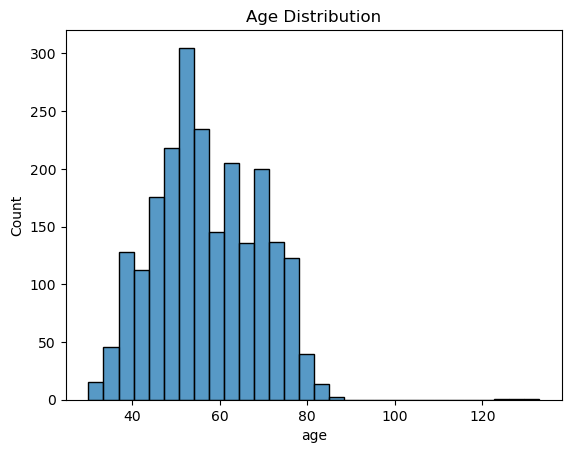

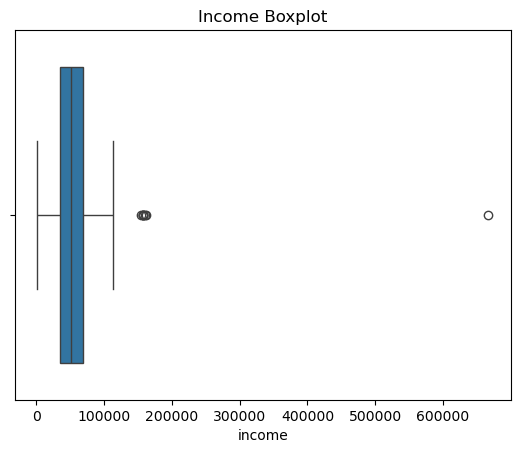

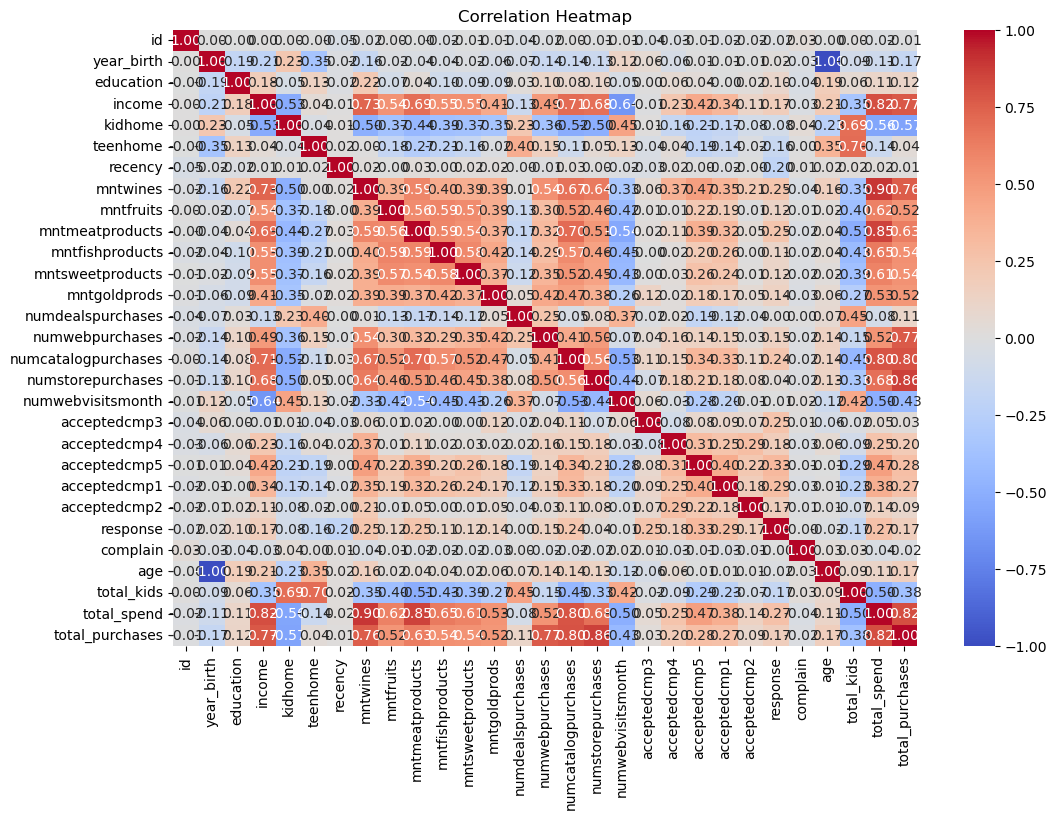

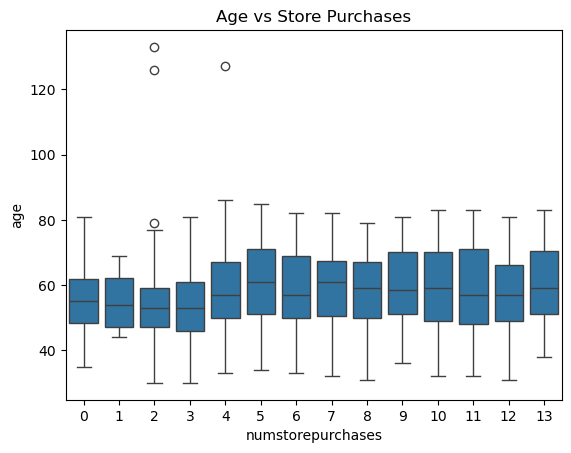

T-test (Web Purchases with/without kids): TtestResult(statistic=np.float64(-3.4776680357907725), pvalue=np.float64(0.0005154861659012753), df=np.float64(2230.0))
Web vs Store Purchase Correlation: PearsonRResult(statistic=np.float64(0.4990298499362478), pvalue=np.float64(7.042115192014363e-141))


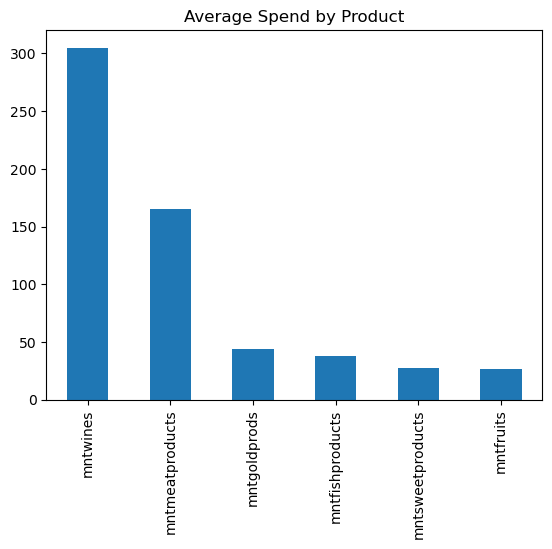

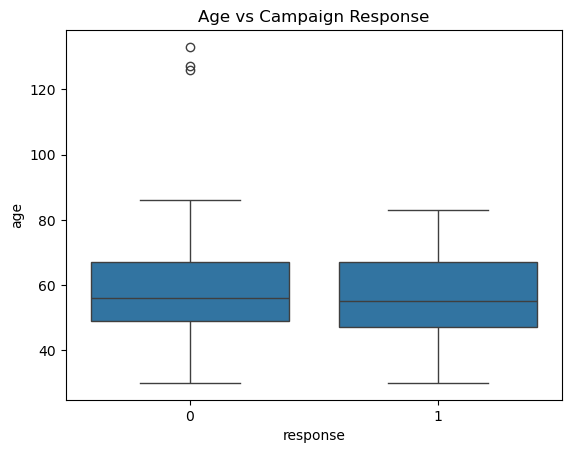

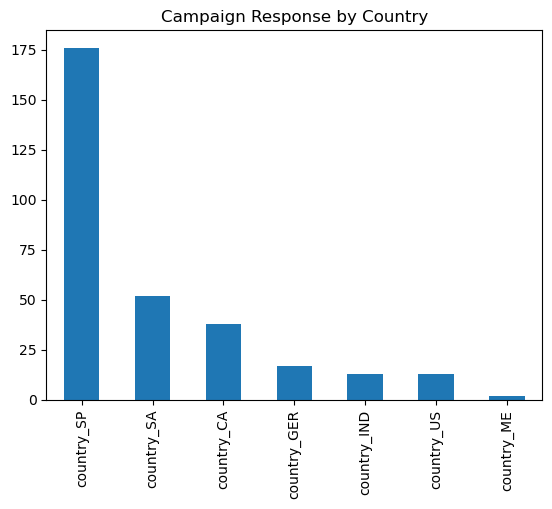

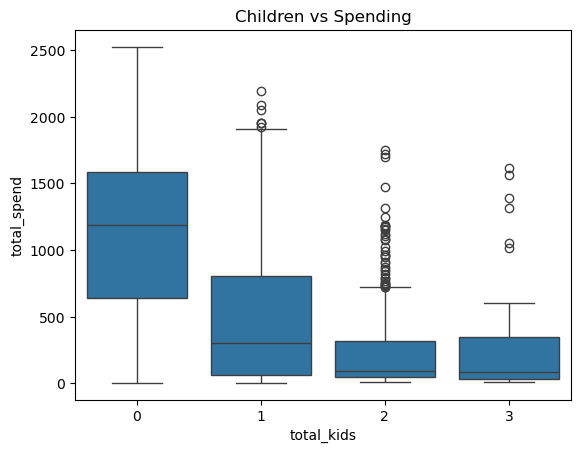

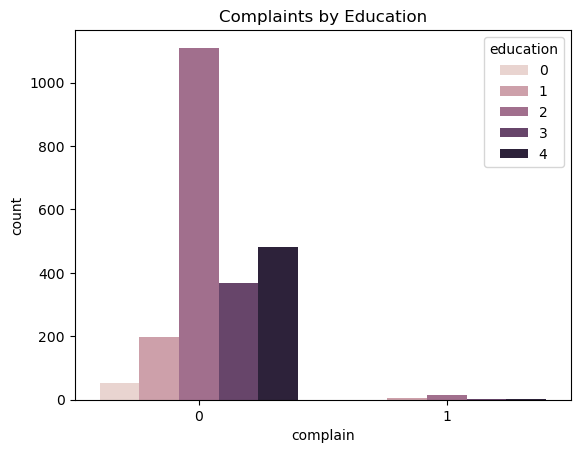

In [3]:
# MARKETING CAMPAIGN PROJECT - BULLETPROOF & FIXED VERSION

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import scipy.stats as stats

# STEP 1: LOAD THE DATA WITH CORRECT PARSING
df = pd.read_csv(r"C:\Users\srini\Downloads\1736837301_datasets (1)\marketing_data.csv")

# STEP 2: CLEAN AND NORMALIZE COLUMN NAMES
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
print("✅ Normalized Columns:")
print(df.columns.tolist())

# STEP 3: HANDLE DATE
if 'dt_customer' in df.columns:
    df['dt_customer'] = pd.to_datetime(df['dt_customer'], errors='coerce')
else:
    print("'dt_customer' column not found. Skipping date parsing.")

# STEP 4: CLEAN CATEGORICAL TEXT COLUMNS
if 'education' in df.columns:
    df['education'] = df['education'].str.strip().str.title()
else:
    print("'education' column not found.")

if 'marital_status' in df.columns:
    df['marital_status'] = df['marital_status'].str.strip().str.title()
else:
    print("'marital_status' column not found.")

# STEP 5: CLEAN INCOME FIELD
if 'income' in df.columns:
    df['income'] = df['income'].replace('[\$,]', '', regex=True).astype(float)

# STEP 6: FILL MISSING INCOME
if 'income' in df.columns and 'education' in df.columns and 'marital_status' in df.columns:
    df['income'] = df.groupby(['education', 'marital_status'])['income'].transform(lambda x: x.fillna(x.mean()))
else:
    print("Missing required columns to impute income.")

# STEP 7: FEATURE ENGINEERING
if 'year_birth' in df.columns:
    df['age'] = datetime.now().year - df['year_birth']
else:
    df['age'] = np.nan
    print("'year_birth' column missing. Age set to NaN.")

if 'kidhome' in df.columns and 'teenhome' in df.columns:
    df['total_kids'] = df['kidhome'] + df['teenhome']
else:
    df['total_kids'] = 0
    print("'kidhome' or 'teenhome' missing. total_kids set to 0.")

product_cols = [col for col in ['mntwines', 'mntfruits', 'mntmeatproducts',
                                'mntfishproducts', 'mntsweetproducts', 'mntgoldprods'] if col in df.columns]
df['total_spend'] = df[product_cols].sum(axis=1)

purchase_cols = [col for col in ['numwebpurchases', 'numcatalogpurchases', 'numstorepurchases'] if col in df.columns]
df['total_purchases'] = df[purchase_cols].sum(axis=1)

# STEP 8: VISUALIZATIONS
if 'age' in df.columns:
    sns.histplot(df['age'].dropna(), bins=30)
    plt.title("Age Distribution")
    plt.show()

if 'income' in df.columns:
    sns.boxplot(x=df['income'].dropna())
    plt.title("Income Boxplot")
    plt.show()

# STEP 9: OUTLIER REMOVAL
if 'income' in df.columns:
    Q1 = df['income'].quantile(0.25)
    Q3 = df['income'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df['income'] >= Q1 - 1.5 * IQR) & (df['income'] <= Q3 + 1.5 * IQR)]

# STEP 10: ENCODING
if 'education' in df.columns:
    education_order = ['Basic', '2N Cycle', 'Graduation', 'Master', 'Phd']
    df['education'] = pd.Categorical(df['education'], categories=education_order, ordered=True).codes

if 'marital_status' in df.columns:
    df = pd.get_dummies(df, columns=['marital_status'], drop_first=True)
if 'country' in df.columns:
    df = pd.get_dummies(df, columns=['country'], drop_first=True)

# STEP 11: CORRELATION HEATMAP (NUMERIC-ONLY)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# STEP 12: HYPOTHESIS TESTING
if 'numstorepurchases' in df.columns and 'age' in df.columns:
    sns.boxplot(x='numstorepurchases', y='age', data=df)
    plt.title("Age vs Store Purchases")
    plt.show()

if 'numwebpurchases' in df.columns:
    df['has_children'] = df['total_kids'] > 0
    print("T-test (Web Purchases with/without kids):", 
          stats.ttest_ind(df[df['has_children']]['numwebpurchases'], 
                          df[~df['has_children']]['numwebpurchases']))

if 'numwebpurchases' in df.columns and 'numstorepurchases' in df.columns:
    print("Web vs Store Purchase Correlation:", 
          stats.pearsonr(df['numwebpurchases'], df['numstorepurchases']))

if 'country_usa' in df.columns:
    us = df[df['country_usa'] == 1]['total_purchases']
    non_us = df[df['country_usa'] == 0]['total_purchases']
    print("T-test US vs Non-US:", stats.ttest_ind(us, non_us))

# STEP 13: PRODUCT ANALYSIS
if product_cols:
    df[product_cols].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title("Average Spend by Product")
    plt.show()

# STEP 14: AGE vs CAMPAIGN RESPONSE
if 'response' in df.columns and 'age' in df.columns:
    sns.boxplot(x='response', y='age', data=df)
    plt.title("Age vs Campaign Response")
    plt.show()

# STEP 15: COUNTRY WITH MOST ACCEPTANCE
country_cols = [col for col in df.columns if col.startswith("country_")]
if 'response' in df.columns and country_cols:
    response_by_country = {col: df[df[col] == 1]['response'].sum() for col in country_cols}
    pd.Series(response_by_country).sort_values(ascending=False).plot(kind='bar')
    plt.title("Campaign Response by Country")
    plt.show()

# STEP 16: KIDS vs SPENDING
if 'total_kids' in df.columns and 'total_spend' in df.columns:
    sns.boxplot(x='total_kids', y='total_spend', data=df)
    plt.title("Children vs Spending")
    plt.show()

# STEP 17: EDUCATION vs COMPLAIN
if 'complain' in df.columns and 'education' in df.columns:
    sns.countplot(x='complain', hue='education', data=df)
    plt.title("Complaints by Education")
    plt.show()
